#0 Environment Setup and Installations

In [ ]:
# 0. Environment Setup and Installations

# 1. Mount Google Drive to access your files
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

# 2. Extract the balanced dataset directly to the working directory
print("Unzipping Dataset... this might take a few minutes.")
!rm -rf /content/dataset
os.makedirs("/content/dataset", exist_ok=True)
zip_path = "/content/drive/MyDrive/Deepfake_Project/CelebA_HQ_Balanced_ZeroShot_v2.zip"
!unzip -q "{zip_path}" -d "/content/dataset"
print("Unzip complete!")

# 3. Install necessary libraries
print("Installing required libraries...")
!pip install -q transformers accelerate bitsandbytes torch torchvision Pillow tqdm pandas scikit-learn matplotlib seaborn
print("Installations complete! Ready for Data Extraction.")

Mounted at /content/drive
Unzipping Dataset... this might take a few minutes.
Unzip complete!
Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.1 MB/s eta 0:00:00
Installations complete! Ready for Data Extraction.


#1 copy img from drive

In [ ]:
# Define Paths
import os
import glob

# define the paths
real_dir = '/content/dataset/real'
fake_dir = '/content/dataset/fake'

# scan all the images
real_images = glob.glob(f"{real_dir}/*.*")
fake_images = glob.glob(f"{fake_dir}/*.*")

print(" Data Loading Summary:")
print(f"Found {len(real_images)} REAL images.")
print(f"Found {len(fake_images)} FAKE images.")

if len(real_images) == 0 or len(fake_images) == 0:
    print(" ERROR: Missing images! Check your extraction process in Cell 0.")
else:
    print(f" Total: {len(real_images) + len(fake_images)} images accurately loaded and mapped.")

 Data Loading Summary:
Found 20856 REAL images.
Found 20856 FAKE images.
 Total: 41712 images accurately loaded and mapped.


#2. Model Initialization


In [ ]:
# --- Model Initialization + Load Fine-Tuned Weights ---

from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print(" Loading Processor...")
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

print(" Loading Base Model in bfloat16...")
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- Load Fine-Tuned Q-Former Weights ---
weights_path = '/content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth'

print(f" Loading Q-Former weights from {weights_path}...")
checkpoint = torch.load(weights_path, map_location=device)

# Load the fine tuned weights into the Q-former
model.qformer.load_state_dict(checkpoint)
print(" Q-Former weights loaded successfully!")

# --- Freeze everything for Inference ---
# the model just evaluates
for param in model.parameters():
    param.requires_grad = False

model.eval()
print("Model ready for evaluation!")

 Loading Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/104k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

 Loading Q-Former weights from /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth...
 Q-Former weights loaded successfully!
Model ready for evaluation!


#3. Dataset Loading

In [ ]:
import os
import glob
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import multiprocessing

# Custom Dataset class inheriting from PyTorch Dataset
class PreExtractedDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx] # Get a single row from the DataFrame
        image_path = row['image_path']
        label_str = row['label'] # Expected: "Yes" (Real) or "No" (Fake)

        # Load image and set the exact prompt from the methodology
        image = Image.open(image_path).convert('RGB')
        prompt = "is this photo real?"

        # 1. Process ONLY the base prompt and image
        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()} #Remove the extra batch dimension added by the processor, This allows the DataLoader to stack them into real batches later

        # 2. Pass the plain text label directly to the batch dictionary for evaluation
        inputs['text_label'] = label_str
        return inputs

# --- Paths updated for CelebsHQ Balanced Dataset ---
base_dir = '/content/dataset'

fake_images_folder = os.path.join(base_dir, 'fake')
real_images_folder = os.path.join(base_dir, 'real')

all_paths = []
all_labels = []

# Collect Fake images (Recursive glob to catch nested folders if any)
# Find all fake images and assign the label "No"
if os.path.exists(fake_images_folder):
    fake_paths = glob.glob(os.path.join(fake_images_folder, '**', '*.*'), recursive=True)
    fake_paths = [p for p in fake_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_paths.extend(fake_paths)
    all_labels.extend(["No"] * len(fake_paths))
else:
    print(f" Warning: fake folder not found at {fake_images_folder}")

# Collect Real images (Recursive glob)
# Find all real images and assign the label "Yes" (meaning: is real)
if os.path.exists(real_images_folder):
    real_paths = glob.glob(os.path.join(real_images_folder, '**', '*.*'), recursive=True)
    real_paths = [p for p in real_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_paths.extend(real_paths)
    all_labels.extend(["Yes"] * len(real_paths))
else:
    print(f" Warning: real folder not found at {real_images_folder}")

print(f" Total images found: {len(all_paths)}")

if len(all_paths) > 0:
    # 1. Create a Pandas DataFrame
    test_df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})
    print(f" Testing images (Fine-Tuned Celebs-HQ): {len(test_df)}")

    # 2. Create Dataset
    test_dataset = PreExtractedDeepfakeDataset(test_df, processor)

    # Calculate automatically the amount of free threads
    optimal_workers = min(8, multiprocessing.cpu_count())

    # 3. Create DataLoader
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=optimal_workers,
        pin_memory=True,
        prefetch_factor=2
    )
    print(" test_dataloader created successfully for Fine-Tuned Evaluation!")
else:
    print(" ERROR: No images loaded. Please verify the subfolder names inside /content/dataset")

 Total images found: 41712
 Testing images (Fine-Tuned Celebs-HQ): 41712
 test_dataloader created successfully for Fine-Tuned Evaluation!


#4. Model Evaltauion

In [ ]:
# --- 4. Probabilistic Evaluation Loop + Embeddings Extraction (CelebA-HQ Fine-Tuned) ---

import os
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
from tqdm import tqdm

model.eval()

all_fake_probabilities = []
all_true_numerical_labels = []
all_embeddings = [] # Added for t-SNE

# Define tokens and extract de-duplicated token IDs
yes_tokens = ["Yes", "yes", " Yes", " yes"]
no_tokens  = ["No",  "no",  " No",  " no"]
yes_token_ids = list(set([processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]))
no_token_ids  = list(set([processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]))

yes_tensor = torch.tensor(yes_token_ids, device=device)
no_tensor  = torch.tensor(no_token_ids, device=device)

print("--- Starting Fine-Tuned Evaluation on CelebA-HQ ---")
print(f"Tokenizer Padding Side: {processor.tokenizer.padding_side}")

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_dataloader, desc="Evaluating Test Set")):

        pixel_values = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Robust True Label Extraction
        text_labels = batch['text_label']
        numerical_labels = torch.tensor(
            [1 if "no" in str(label).lower() or "fake" in str(label).lower() else 0 for label in text_labels]
        )

        # ----------------- 1. Embeddings extraction ----------------------
        # Extract deep features from the Q-Former for t-SNE
        qformer_outputs = model.qformer(
            input_ids=qformer_input_ids,
            attention_mask=qformer_attention_mask,
            query_embeds=model.query_tokens.expand(pixel_values.shape[0], -1, -1),
            encoder_hidden_states=model.vision_model(pixel_values).last_hidden_state,
        )
        embedding = qformer_outputs.last_hidden_state.mean(dim=1)
        all_embeddings.extend(embedding.cpu().float().numpy())

        # ------------------ 2. Probabilistic inference -------------------
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        first_token_logits = outputs.scores[0]

        # Extract logits using MAX over de-duplicated IDs
        yes_logits = first_token_logits[:, yes_tensor].max(dim=-1).values
        no_logits  = first_token_logits[:, no_tensor].max(dim=-1).values

        # Normalize via softmax over the {Yes, No} subset
        pair_logits = torch.stack([yes_logits, no_logits], dim=-1)
        pair_probs  = torch.softmax(pair_logits, dim=-1)
        fake_probability = pair_probs[:, 1]

        # Collect results
        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# ------------------------- Metrics & Saving --------------------------------
all_probs  = np.array(all_fake_probabilities)
all_labels = np.array(all_true_numerical_labels)

# Save arrays to Drive
save_dir = '/content/drive/MyDrive/Deepfake_Project/FineTuned_Results_CelebsHQ'
os.makedirs(save_dir, exist_ok=True)
np.save(f'{save_dir}/FineTuned_probs.npy', all_probs)
np.save(f'{save_dir}/FineTuned_labels.npy', all_labels)
np.save(f'{save_dir}/FineTuned_embeddings.npy', np.array(all_embeddings))
print(f"Saved inference results to: {save_dir}")

# Calculate metrics
auc_score = roc_auc_score(all_labels, all_probs)

# Find optimal threshold iteratively (Updated from DF-v2)
thresholds = np.arange(0.1, 0.91, 0.01)
accuracies = [accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(accuracies)
best_thresh = thresholds[best_idx]
best_acc = accuracies[best_idx]

# Calculate advanced industry metrics
binary_preds = (all_probs >= best_thresh).astype(int)
f1 = f1_score(all_labels, binary_preds)
precision = precision_score(all_labels, binary_preds)
recall = recall_score(all_labels, binary_preds)

print(f"\nFinal Test ROC-AUC Score: {auc_score:.4f}")
print(f"Optimal Threshold: {best_thresh:.2f} | ACC: {best_acc*100:.2f}% | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

--- Starting Fine-Tuned Evaluation on CelebA-HQ ---
Tokenizer Padding Side: left


Evaluating Test Set: 100%|██████████| 1304/1304 [07:22<00:00,  2.95it/s]


Saved inference results to: /content/drive/MyDrive/Deepfake_Project/FineTuned_Results_CelebsHQ

Final Test ROC-AUC Score: 0.7654
Optimal Threshold: 0.33 | ACC: 70.94% | F1: 0.6737 | Precision: 0.7681 | Recall: 0.5999


#5. Graphs

Calculating Bootstrap Confidence Intervals (1000 iterations)...
Final ROC-AUC: 0.7654 (95% CI: [0.7608, 0.7702])


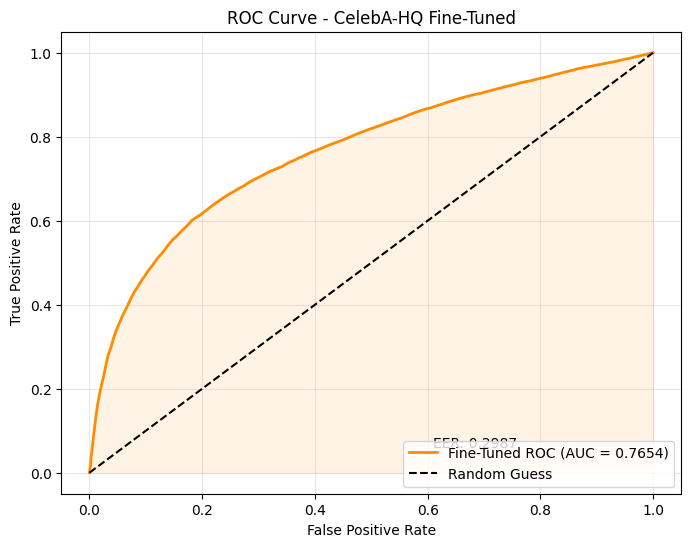

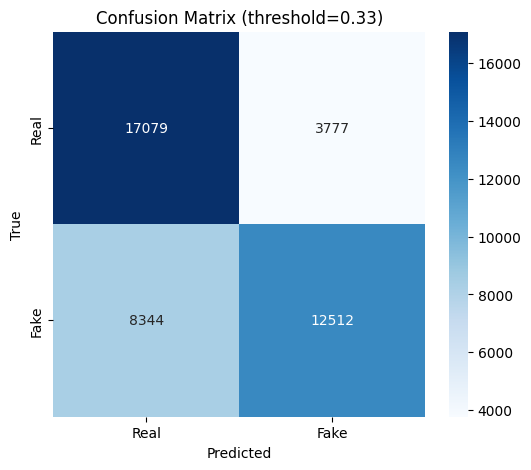

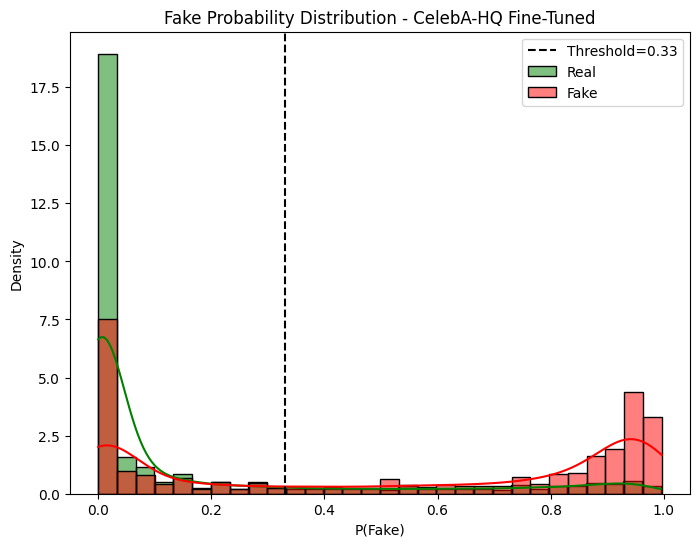

Generating t-SNE Visualization...
Silhouette Score: 0.0853


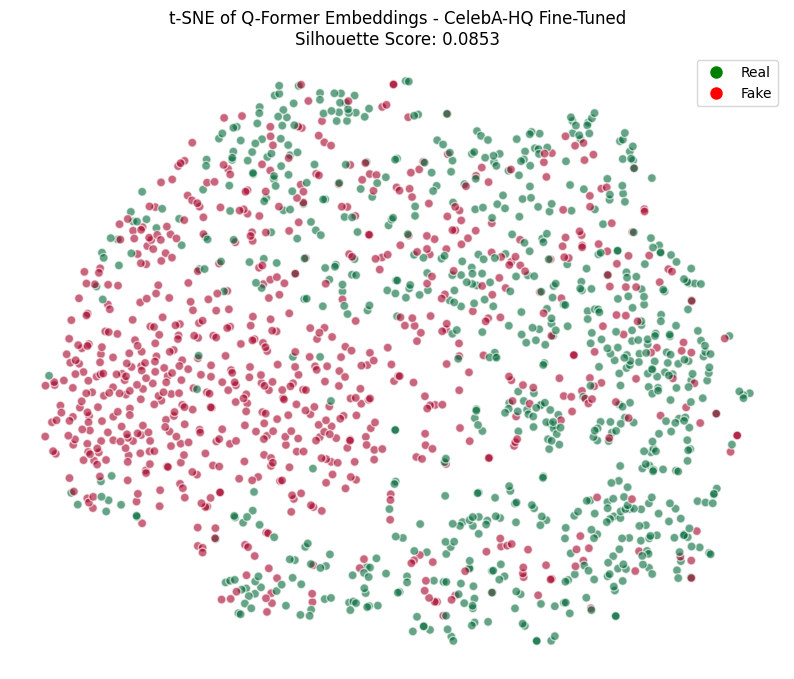


✅ All graphs saved to: /content/drive/MyDrive/Deepfake_Project/FineTuned_Results_CelebsHQ/Graphs


In [ ]:
# --- 5. Advanced Metrics & Visualizations (CelebA-HQ Fine-Tuned) ---

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, silhouette_score, roc_auc_score
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Configuration & Paths
# ---------------------------------------------------------
base_results_dir = '/content/drive/MyDrive/Deepfake_Project/FineTuned_Results_CelebsHQ'
graph_dir = os.path.join(base_results_dir, 'Graphs')
os.makedirs(graph_dir, exist_ok=True)

# Set random seed for reproducibility
rng = np.random.RandomState(42)

# ==========================================
# 1. Bootstrap Confidence Intervals (95% CI)
# ==========================================
print("Calculating Bootstrap Confidence Intervals (1000 iterations)...")
bootstrapped_aucs = []

for _ in range(1000):
    indices = rng.randint(0, len(all_probs), len(all_probs))
    if len(np.unique(all_labels[indices])) < 2:
        continue
    bootstrapped_aucs.append(roc_auc_score(all_labels[indices], all_probs[indices]))

sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f"Final ROC-AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")

# ==========================================
# 2. ROC Curve & EER
# ==========================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)

# Calculate Equal Error Rate (EER)
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Fine-Tuned ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add EER text
plt.text(0.6, 0.1, f'EER: {eer:.4f}', transform=plt.gca().transAxes, fontsize=10)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CelebA-HQ Fine-Tuned')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_Fine-Tuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. Confusion Matrix
# ==========================================
binary_preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_Fine-Tuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Probability Distribution
# ==========================================
plt.figure(figsize=(8, 6))
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==0],
             color='green', label='Real', kde=True, stat="density", alpha=0.5, bins=30)
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==1],
             color='red',   label='Fake', kde=True, stat="density", alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)')
plt.ylabel('Density')
plt.title('Fake Probability Distribution - CelebA-HQ Fine-Tuned')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_Fine-Tuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. t-SNE + Silhouette Score
# ==========================================
print("Generating t-SNE Visualization...")
# Sample up to 1500 embeddings to save time
sample_size = min(1500, len(all_embeddings))
indices = rng.choice(len(all_embeddings), sample_size, replace=False)
sampled_embeddings = np.array(all_embeddings)[indices]
sampled_labels     = all_labels[indices]

sil_score = silhouette_score(sampled_embeddings, sampled_labels)
print(f"Silhouette Score: {sil_score:.4f}")

embeddings_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(sampled_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=sampled_labels, cmap=plt.cm.RdYlGn_r, alpha=0.6, edgecolors='w', s=40)
custom_lines = [Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10)]
plt.legend(custom_lines, ['Real', 'Fake'])
plt.title(f't-SNE of Q-Former Embeddings - CelebA-HQ Fine-Tuned\nSilhouette Score: {sil_score:.4f}')
plt.axis('off')
plt.savefig(os.path.join(graph_dir, 'tsne_Fine-Tuned.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n All graphs saved to: {graph_dir}")